### Cell 1: Setup and Imports

In [1]:
# Cell 1: Setup and Imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torchvision
from torchvision import transforms
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay
)
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Imports loaded successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

Imports loaded successfully!
PyTorch version: 2.13.0+cpu
NumPy version: 2.5.1


### Cell 2: Configure Paths

In [2]:
# Cell 2: Add project root to Python path
import sys
import os

# Get current working directory (should be notebooks/)
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)  # Go up one level

# Add project root to sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root added to path: {project_root}")
print(f"sys.path now includes: {sys.path[:3]}...")

Project root added to path: d:\IT-Project-2
sys.path now includes: ['d:\\IT-Project-2', 'd:\\Python\\python313.zip', 'd:\\Python\\DLLs']...


### Cell 3: Dataset Statistics

In [3]:
# Cell 3: Configure Paths
# Get the absolute path to project root (already set in Cell 2)
if 'project_root' not in dir():
    import os
    project_root = os.path.dirname(os.getcwd())  # Fallback

DATA_ROOT = os.path.join(project_root, "data", "chest_xray")
MODELS_DIR = os.path.join(project_root, "models")
OUTPUT_DIR = os.path.join(project_root, "outputs", "eda")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Data path: {DATA_ROOT}")
print(f"Models path: {MODELS_DIR}")
print(f"Output path: {OUTPUT_DIR}")

Project root: d:\IT-Project-2
Data path: d:\IT-Project-2\data\chest_xray
Models path: d:\IT-Project-2\models
Output path: d:\IT-Project-2\outputs\eda


### Cell 4: Dataset Distribution Visualization

In [4]:
# Cell 4: Dataset Statistics
from src.data.dataset import ChestXRayDataset

# Load dataset statistics
splits = ['train', 'val', 'test']
stats = {}

for split in splits:
    dataset = ChestXRayDataset(DATA_ROOT, split=split)
    class_counts = dataset.get_class_distribution()
    stats[split] = {
        'total': len(dataset),
        'normal': class_counts.get(0, 0),
        'pneumonia': class_counts.get(1, 0)
    }
    print(f"\n{split.upper()} Split:")
    print(f"  Total images: {len(dataset)}")
    print(f"  NORMAL: {class_counts.get(0, 0)} images")
    print(f"  PNEUMONIA: {class_counts.get(1, 0)} images")

# Create summary DataFrame
df_stats = pd.DataFrame(stats).T
df_stats['normal_pct'] = (df_stats['normal'] / df_stats['total'] * 100).round(1)
df_stats['pneumonia_pct'] = (df_stats['pneumonia'] / df_stats['total'] * 100).round(1)
display(df_stats)


TRAIN Split:
  Total images: 5216
  NORMAL: 1341 images
  PNEUMONIA: 3875 images

VAL Split:
  Total images: 16
  NORMAL: 8 images
  PNEUMONIA: 8 images

TEST Split:
  Total images: 624
  NORMAL: 234 images
  PNEUMONIA: 390 images


,total,normal,pneumonia,normal_pct,pneumonia_pct
train,5216,1341,3875,25.7,74.3
val,16,8,8,50.0,50.0
test,624,234,390,37.5,62.5


### Cell 5: Load and Display Sample Images

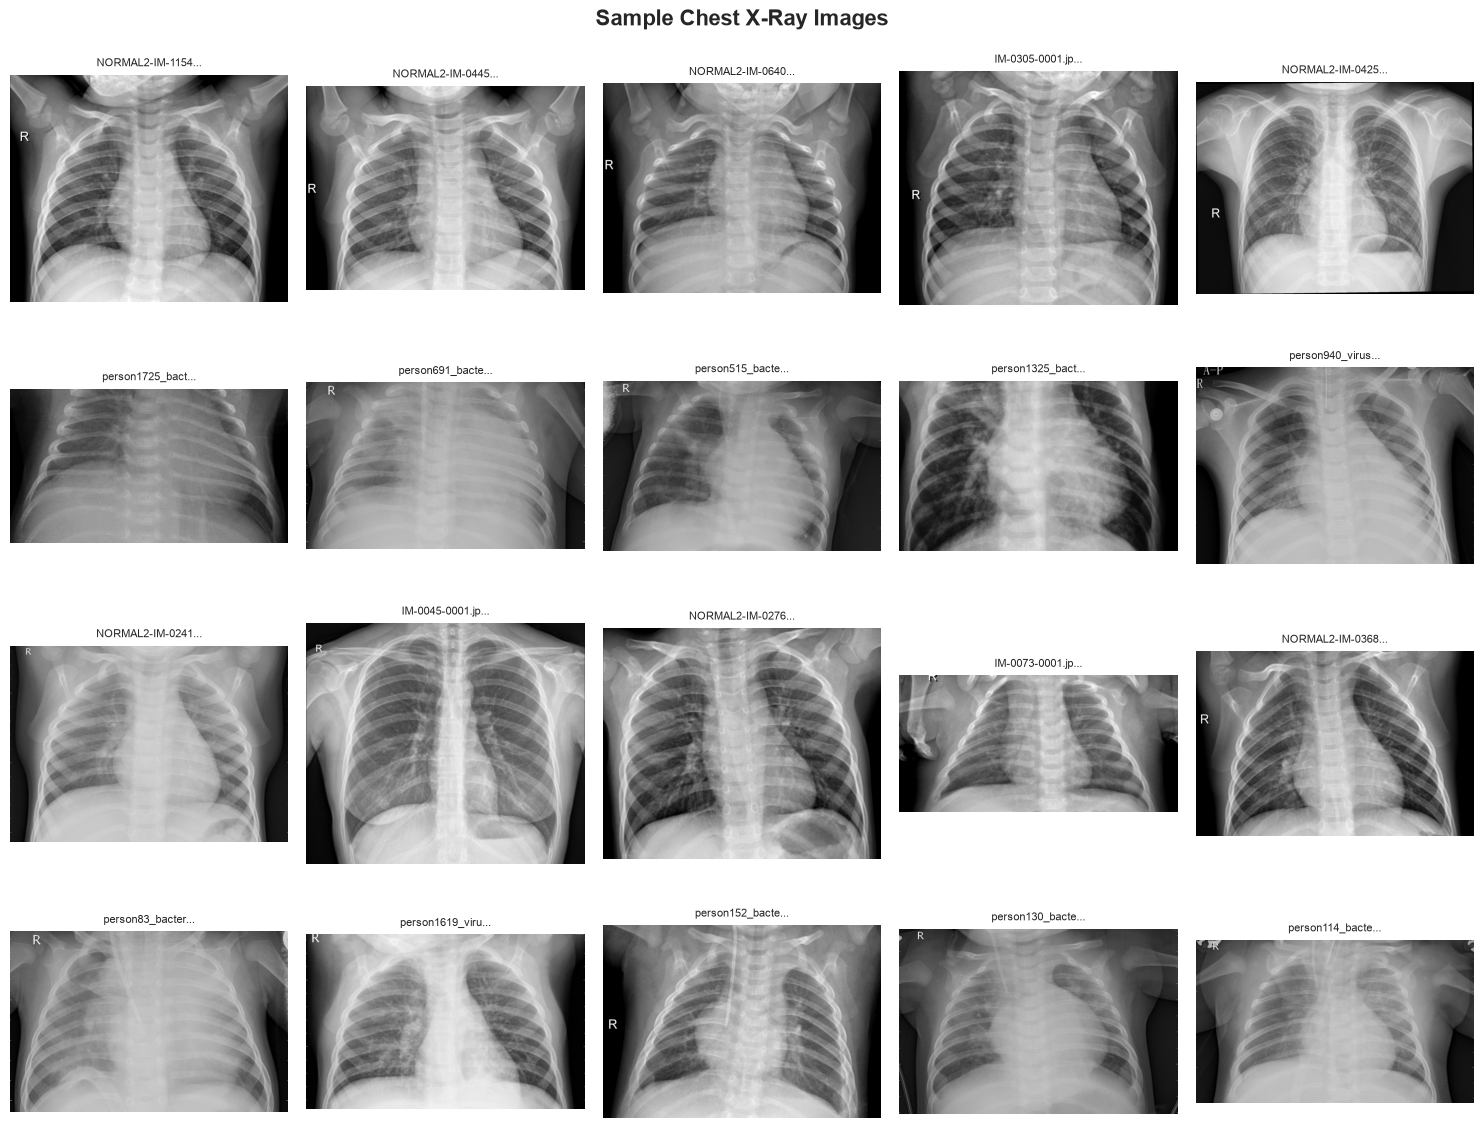

Saved to d:\IT-Project-2\outputs\eda/sample_images.png


In [5]:
# Cell 5: Load and Display Sample Images
import random
from PIL import Image

def load_sample_images(split, class_name, num_samples=5):
    """Load sample images from a specific split and class."""
    class_dir = os.path.join(DATA_ROOT, split, class_name)
    if not os.path.exists(class_dir):
        return []
    files = [f for f in os.listdir(class_dir) 
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    sample_files = random.sample(files, min(num_samples, len(files)))
    images = []
    for f in sample_files:
        img_path = os.path.join(class_dir, f)
        img = Image.open(img_path).convert('RGB')
        images.append((img, f))
    return images

# Get samples
normal_train = load_sample_images('train', 'NORMAL', 5)
pneumonia_train = load_sample_images('train', 'PNEUMONIA', 5)
normal_test = load_sample_images('test', 'NORMAL', 5)
pneumonia_test = load_sample_images('test', 'PNEUMONIA', 5)

# Display samples
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Sample Chest X-Ray Images', fontsize=16, fontweight='bold')

for row, (images, title) in enumerate([
    (normal_train, 'NORMAL - Train'),
    (pneumonia_train, 'PNEUMONIA - Train'),
    (normal_test, 'NORMAL - Test'),
    (pneumonia_test, 'PNEUMONIA - Test')
]):
    for col in range(5):
        ax = axes[row, col]
        if col < len(images):
            img, fname = images[col]
            ax.imshow(img, cmap='gray')
            ax.set_title(fname[:15] + '...', fontsize=8)
        else:
            ax.axis('off')
        ax.axis('off')
    
    # Add row label
    axes[row, 0].set_ylabel(title, fontsize=12, fontweight='bold', rotation=90, labelpad=20)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sample_images.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_DIR}/sample_images.png")

### Cell 6: Image Size Analysis

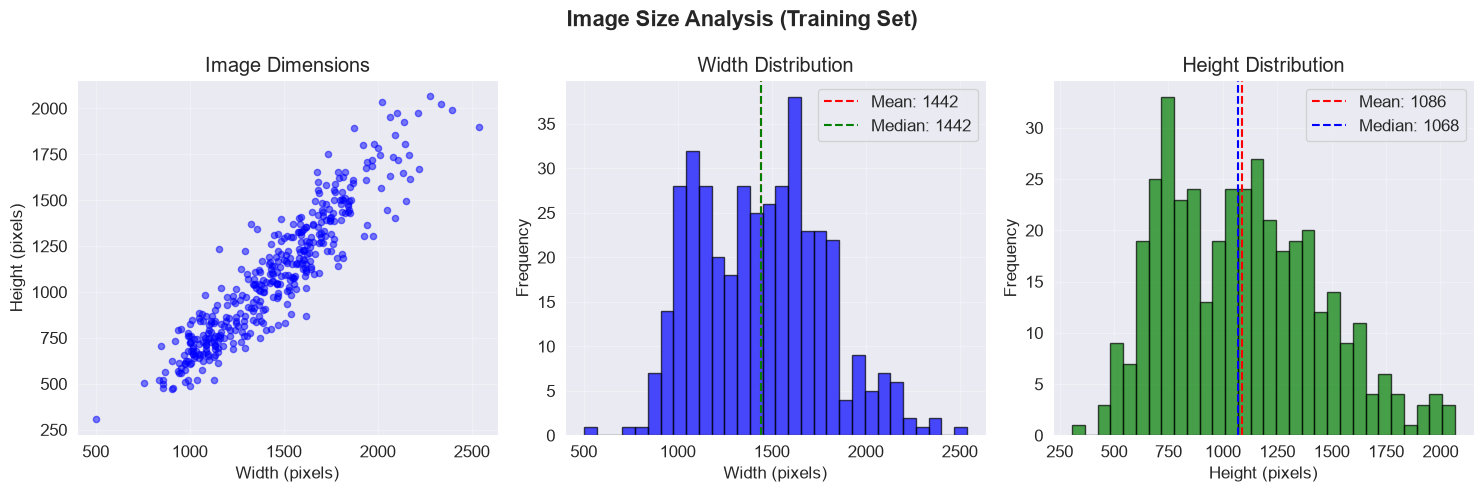

Saved to d:\IT-Project-2\outputs\eda/image_size_analysis.png


In [6]:
# Cell 6: Image Size Analysis
def analyze_image_sizes(split, max_samples=100):
    """Analyze image dimensions for a split."""
    sizes = []
    for class_name in ['NORMAL', 'PNEUMONIA']:
        class_dir = os.path.join(DATA_ROOT, split, class_name)
        if not os.path.exists(class_dir):
            continue
        files = [f for f in os.listdir(class_dir) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for f in files[:max_samples]:
            img_path = os.path.join(class_dir, f)
            try:
                img = Image.open(img_path)
                sizes.append((img.width, img.height))
            except:
                continue
    return sizes

# Analyze training images
train_sizes = analyze_image_sizes('train', max_samples=200)

if train_sizes:
    widths = [s[0] for s in train_sizes]
    heights = [s[1] for s in train_sizes]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Scatter plot of dimensions
    axes[0].scatter(widths, heights, alpha=0.5, c='blue', s=20)
    axes[0].set_xlabel('Width (pixels)')
    axes[0].set_ylabel('Height (pixels)')
    axes[0].set_title('Image Dimensions')
    axes[0].grid(True, alpha=0.3)
    
    # Histogram of widths
    axes[1].hist(widths, bins=30, color='blue', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Width (pixels)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Width Distribution')
    axes[1].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}')
    axes[1].axvline(np.median(widths), color='green', linestyle='--', label=f'Median: {np.median(widths):.0f}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Histogram of heights
    axes[2].hist(heights, bins=30, color='green', alpha=0.7, edgecolor='black')
    axes[2].set_xlabel('Height (pixels)')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Height Distribution')
    axes[2].axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean: {np.mean(heights):.0f}')
    axes[2].axvline(np.median(heights), color='blue', linestyle='--', label=f'Median: {np.median(heights):.0f}')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle('Image Size Analysis (Training Set)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/image_size_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved to {OUTPUT_DIR}/image_size_analysis.png")

### Cell 7: Load Saved Model and Results

In [7]:
# Cell 7: Load Saved Model and Results
import torch
from src.models.builder import build_model
from src.training.config import TrainConfig

def load_model_and_results():
    """Load the trained model and results."""
    config = TrainConfig()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Build model
    model = build_model(config.model_name, num_classes=2, pretrained=False)
    
    # Use absolute path based on project_root
    model_path = os.path.join(MODELS_DIR, "best_model.pth")
    
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.to(device)
        model.eval()
        print(f"Model loaded from: {model_path}")
        return model, device, config
    else:
        print(f"Model not found at: {model_path}")
        print(f"   Check that the model exists in {MODELS_DIR}")
        return None, device, config

model, device, config = load_model_and_results()

Model loaded from: d:\IT-Project-2\models\best_model.pth


### Cell 8: Evaluate Model on Test Set

In [8]:
# Cell 8: Evaluate Model on Test Set
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(model, test_loader, device):
    """Evaluate model and return metrics."""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

if model is not None:
    # Load test data
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    test_dataset = ChestXRayDataset(DATA_ROOT, 'test', transform)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # Evaluate
    preds, probs, labels = evaluate_model(model, test_loader, device)
    
    # Compute metrics
    accuracy = accuracy_score(labels, preds)
    auc_score = roc_auc_score(labels, probs)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    
    print("="*60)
    print("TEST SET EVALUATION RESULTS")
    print("="*60)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC-ROC: {auc_score:.4f}")
    print(f"F1-Macro: {f1_macro:.4f}")
    print(f"F1-Weighted: {f1_weighted:.4f}")
    print("\nClassification Report:")
    print(classification_report(labels, preds, target_names=['NORMAL', 'PNEUMONIA']))

TEST SET EVALUATION RESULTS
Accuracy: 0.8413
AUC-ROC: 0.9480
F1-Macro: 0.8095
F1-Weighted: 0.8290

Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      0.58      0.73       234
   PNEUMONIA       0.80      1.00      0.89       390

    accuracy                           0.84       624
   macro avg       0.90      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624



### Cell 9: Confusion Matrix Visualization

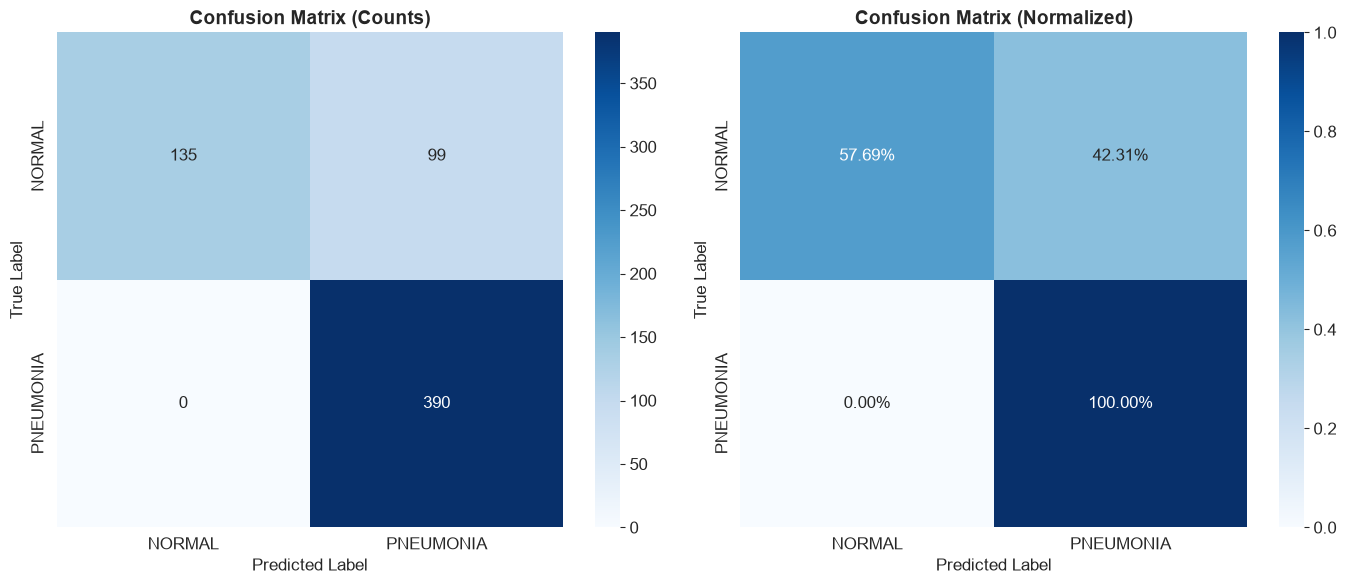

Saved to d:\IT-Project-2\outputs\eda/confusion_matrix.png


In [9]:
# Cell 9: Confusion Matrix Visualization
from sklearn.metrics import ConfusionMatrixDisplay

if model is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Numerical confusion matrix
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['NORMAL', 'PNEUMONIA'],
                yticklabels=['NORMAL', 'PNEUMONIA'],
                ax=axes[0])
    axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # Normalized confusion matrix
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=['NORMAL', 'PNEUMONIA'],
                yticklabels=['NORMAL', 'PNEUMONIA'],
                ax=axes[1])
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved to {OUTPUT_DIR}/confusion_matrix.png")

### Cell 10: ROC Curve

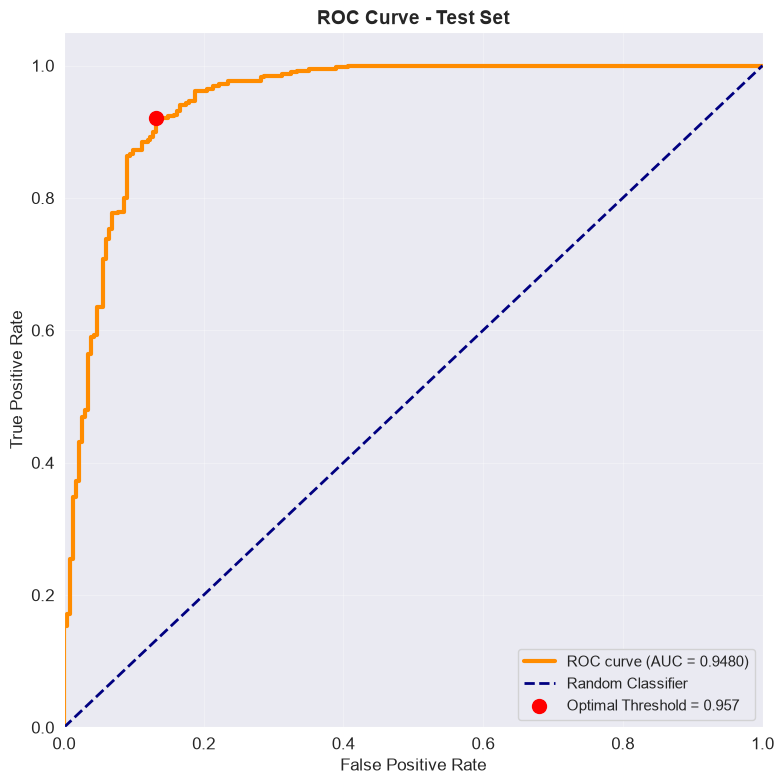

Saved to d:\IT-Project-2\outputs\eda/roc_curve.png
Optimal Threshold: 0.9570


In [10]:
# Cell 10: ROC Curve
if model is not None:
    fpr, tpr, thresholds = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # ROC Curve
    ax.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    
    # Find optimal threshold (Youden's J)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    ax.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, 
               label=f'Optimal Threshold = {optimal_threshold:.3f}', zorder=5)
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curve - Test Set', fontsize=14, fontweight='bold')
    ax.legend(loc="lower right", fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved to {OUTPUT_DIR}/roc_curve.png")
    print(f"Optimal Threshold: {optimal_threshold:.4f}")

### Cell 11: Precision-Recall Curve

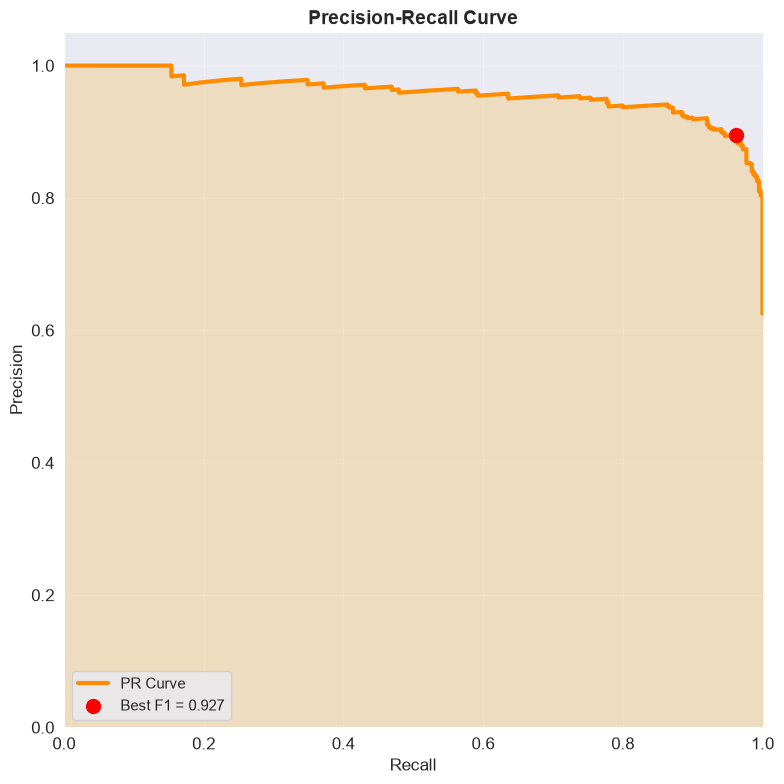

Saved to d:\IT-Project-2\outputs\eda/pr_curve.png


In [11]:
# Cell 11: Precision-Recall Curve
if model is not None:
    precision, recall, thresholds = precision_recall_curve(labels, probs)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # PR Curve
    ax.plot(recall, precision, color='darkorange', lw=3, label='PR Curve')
    ax.fill_between(recall, precision, alpha=0.2, color='orange')
    
    # Find optimal F1 point
    f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
    optimal_f1_idx = np.argmax(f1_scores[:-1])
    ax.scatter(recall[optimal_f1_idx], precision[optimal_f1_idx], color='red', s=100,
               label=f'Best F1 = {f1_scores[optimal_f1_idx]:.3f}', zorder=5)
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    ax.legend(loc="lower left", fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/pr_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved to {OUTPUT_DIR}/pr_curve.png")

### Cell 12: Prediction Confidence Distribution

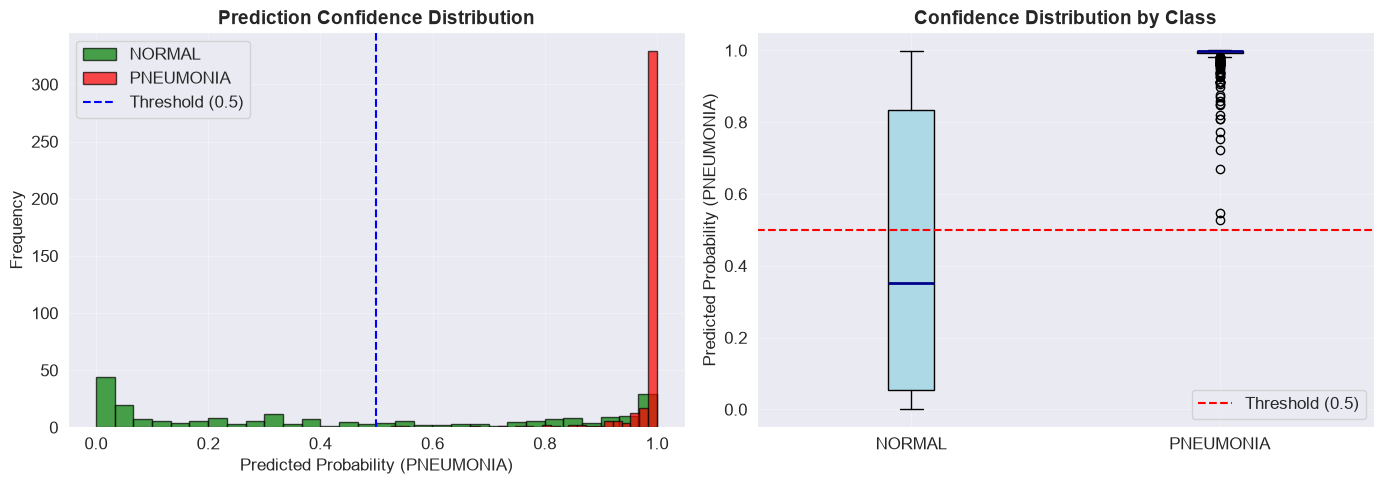

Saved to d:\IT-Project-2\outputs\eda/confidence_distribution.png


In [12]:
# Cell 12: Prediction Confidence Distribution
if model is not None:
    # Ensure probs and labels are defined (they come from Cell 8)
    if 'probs' not in dir() or 'labels' not in dir():
        print("Please run Cell 8 first to get predictions.")
    else:
        # Get confidence for each prediction
        normal_probs = probs[labels == 0]
        pneumonia_probs = probs[labels == 1]
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Histogram of probabilities
        axes[0].hist(normal_probs, bins=30, alpha=0.7, label='NORMAL', color='green', edgecolor='black')
        axes[0].hist(pneumonia_probs, bins=30, alpha=0.7, label='PNEUMONIA', color='red', edgecolor='black')
        axes[0].axvline(0.5, color='blue', linestyle='--', label='Threshold (0.5)')
        axes[0].set_xlabel('Predicted Probability (PNEUMONIA)', fontsize=12)
        axes[0].set_ylabel('Frequency', fontsize=12)
        axes[0].set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Box plot - FIXED: removed deprecated 'labels' argument
        data = [normal_probs, pneumonia_probs]
        bp = axes[1].boxplot(data, patch_artist=True,
                             boxprops=dict(facecolor='lightblue'),
                             medianprops=dict(color='darkblue', linewidth=2))
        # Set tick labels manually
        axes[1].set_xticklabels(['NORMAL', 'PNEUMONIA'])
        axes[1].axhline(0.5, color='red', linestyle='--', label='Threshold (0.5)')
        axes[1].set_ylabel('Predicted Probability (PNEUMONIA)', fontsize=12)
        axes[1].set_title('Confidence Distribution by Class', fontsize=14, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/confidence_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved to {OUTPUT_DIR}/confidence_distribution.png")

### Cell 13: Performance Metrics Bar Chart

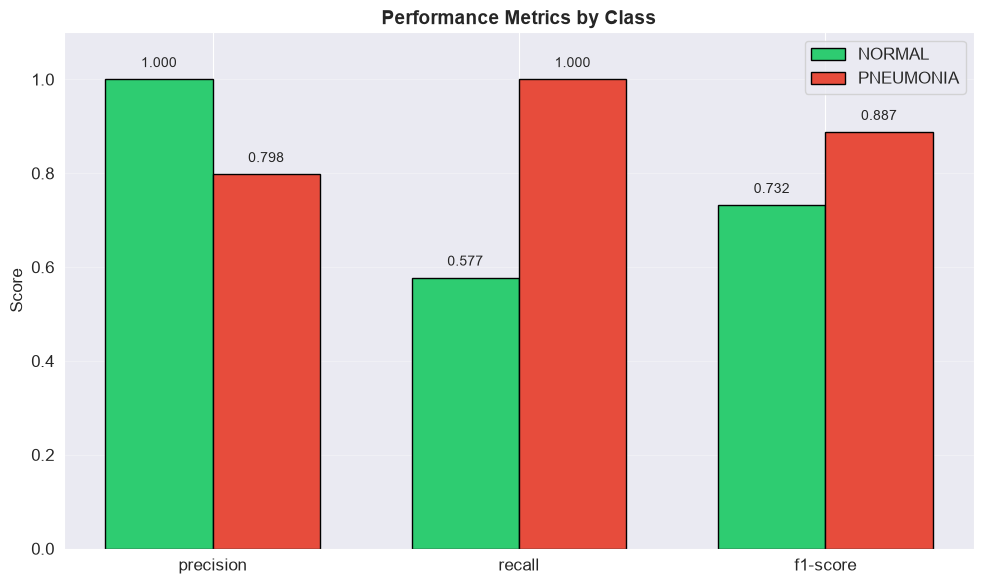

Saved to d:\IT-Project-2\outputs\eda/performance_metrics.png


In [13]:
# Cell 13: Performance Metrics Bar Chart
if model is not None:
    class_names = ['NORMAL', 'PNEUMONIA']
    report = classification_report(labels, preds, target_names=class_names, output_dict=True)
    
    metrics = ['precision', 'recall', 'f1-score']
    normal_values = [report['NORMAL'][m] for m in metrics]
    pneumonia_values = [report['PNEUMONIA'][m] for m in metrics]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(metrics))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, normal_values, width, label='NORMAL', color='#2ecc71', edgecolor='black')
    bars2 = ax.bar(x + width/2, pneumonia_values, width, label='PNEUMONIA', color='#e74c3c', edgecolor='black')
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Performance Metrics by Class', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/performance_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved to {OUTPUT_DIR}/performance_metrics.png")

### Cell 14: Error Analysis

Total misclassified: 99 out of 624 (15.87%)
False Positives (NORMAL → PNEUMONIA): 99
False Negatives (PNEUMONIA → NORMAL): 0


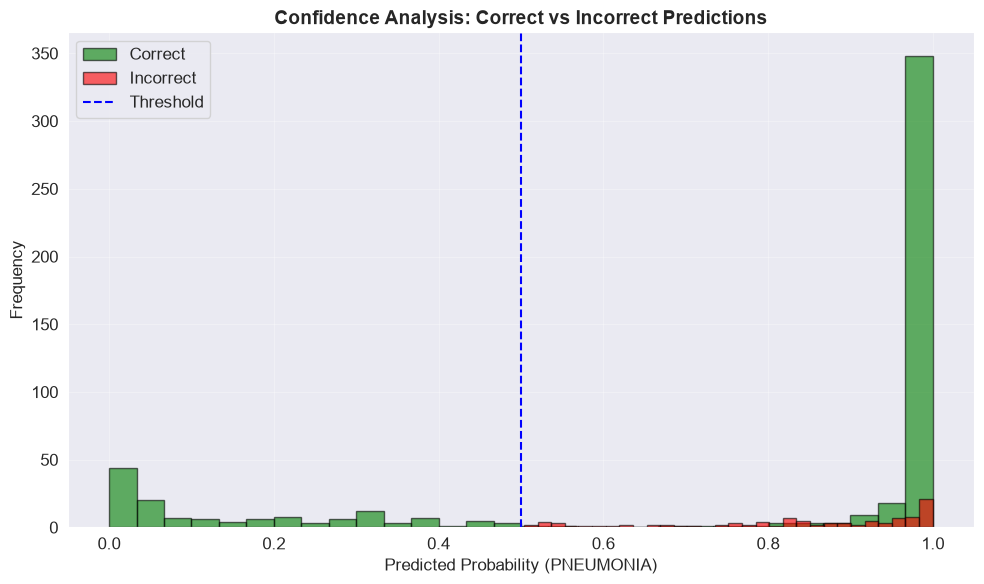

Saved to d:\IT-Project-2\outputs\eda/error_analysis.png


In [14]:
# Cell 14: Error Analysis
if model is not None:
    # Find misclassified samples
    misclassified_mask = preds != labels
    misclassified_indices = np.where(misclassified_mask)[0]
    
    print(f"Total misclassified: {len(misclassified_indices)} out of {len(labels)} ({len(misclassified_indices)/len(labels)*100:.2f}%)")
    
    # Analyze error types
    false_positives = np.where((preds == 1) & (labels == 0))[0]
    false_negatives = np.where((preds == 0) & (labels == 1))[0]
    
    print(f"False Positives (NORMAL → PNEUMONIA): {len(false_positives)}")
    print(f"False Negatives (PNEUMONIA → NORMAL): {len(false_negatives)}")
    
    # Plot confidence vs correctness
    correct_mask = ~misclassified_mask
    correct_conf = probs[correct_mask]
    incorrect_conf = probs[misclassified_mask]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.hist(correct_conf, bins=30, alpha=0.6, label='Correct', color='green', edgecolor='black')
    ax.hist(incorrect_conf, bins=30, alpha=0.6, label='Incorrect', color='red', edgecolor='black')
    ax.axvline(0.5, color='blue', linestyle='--', label='Threshold')
    
    ax.set_xlabel('Predicted Probability (PNEUMONIA)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Confidence Analysis: Correct vs Incorrect Predictions', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/error_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved to {OUTPUT_DIR}/error_analysis.png")

### Cell 15: Summary Report

In [15]:
# Cell 15: Summary Report
if model is not None:
    from datetime import datetime
    
    # Create summary report
    summary = f"""
    ================================================================================
    PNEUMONIA DETECTION - EDA SUMMARY REPORT
    ================================================================================
    Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
    
    DATASET OVERVIEW
    --------------------------------------------------------------------------------
    Training:   {stats['train']['total']} images ({stats['train']['normal']} NORMAL, {stats['train']['pneumonia']} PNEUMONIA)
    Validation: {stats['val']['total']} images ({stats['val']['normal']} NORMAL, {stats['val']['pneumonia']} PNEUMONIA)
    Test:       {stats['test']['total']} images ({stats['test']['normal']} NORMAL, {stats['test']['pneumonia']} PNEUMONIA)
    
    MODEL PERFORMANCE (Test Set)
    --------------------------------------------------------------------------------
    Accuracy:   {accuracy:.4f}
    AUC-ROC:    {auc_score:.4f}
    F1-Macro:   {f1_macro:.4f}
    F1-Weighted:{f1_weighted:.4f}
    
    Classification Report:
    {classification_report(labels, preds, target_names=['NORMAL', 'PNEUMONIA'])}
    
    Confusion Matrix:
    {confusion_matrix(labels, preds)}
    
    Error Analysis:
    --------------------------------------------------------------------------------
    Total Misclassified: {len(misclassified_indices)}
    False Positives: {len(false_positives)} (NORMAL -> PNEUMONIA)
    False Negatives: {len(false_negatives)} (PNEUMONIA -> NORMAL)
    
    ================================================================================
    """
    
    print(summary)
    
    # Save to file with UTF-8 encoding (supports Unicode characters)
    with open(f'{OUTPUT_DIR}/eda_summary.txt', 'w', encoding='utf-8') as f:
        f.write(summary)
    
    print(f"Summary saved to {OUTPUT_DIR}/eda_summary.txt")


    PNEUMONIA DETECTION - EDA SUMMARY REPORT
    Generated: 2026-08-05 12:24:13

    DATASET OVERVIEW
    --------------------------------------------------------------------------------
    Training:   5216 images (1341 NORMAL, 3875 PNEUMONIA)
    Validation: 16 images (8 NORMAL, 8 PNEUMONIA)
    Test:       624 images (234 NORMAL, 390 PNEUMONIA)

    MODEL PERFORMANCE (Test Set)
    --------------------------------------------------------------------------------
    Accuracy:   0.8413
    AUC-ROC:    0.9480
    F1-Macro:   0.8095
    F1-Weighted:0.8290

    Classification Report:
                  precision    recall  f1-score   support

      NORMAL       1.00      0.58      0.73       234
   PNEUMONIA       0.80      1.00      0.89       390

    accuracy                           0.84       624
   macro avg       0.90      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624


    Confusion Matrix:
    [[135  99]
 [  0 390]]

    Error Analysis:
    ----

### Cell 16: Cleanup and Final Status

In [16]:
# Cell 16: Cleanup and Final Status
print("\n" + "="*60)
print("EDA COMPLETED SUCCESSFULLY!")
print("="*60)

print(f"\nAll outputs saved to: {OUTPUT_DIR}")
print("\nGenerated files:")
for f in os.listdir(OUTPUT_DIR):
    file_path = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(file_path):
        size = os.path.getsize(file_path) / 1024
        print(f"  - {f} ({size:.1f} KB)")

print("\nYou can now use these visualizations for your report.")


EDA COMPLETED SUCCESSFULLY!

All outputs saved to: d:\IT-Project-2\outputs\eda

Generated files:
  - confidence_distribution.png (190.4 KB)
  - confusion_matrix.png (174.3 KB)
  - eda_summary.txt (1.5 KB)
  - error_analysis.png (114.9 KB)
  - image_size_analysis.png (403.2 KB)
  - performance_metrics.png (93.6 KB)
  - pr_curve.png (99.9 KB)
  - roc_curve.png (166.2 KB)
  - sample_images.png (6030.5 KB)

You can now use these visualizations for your report.
